<a href="https://colab.research.google.com/github/kanchan874/Machine_vision/blob/main/MV_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install fer opencv-python mtcnn

INFO: pip is looking at multiple versions of facenet-pytorch to determine which version is compatible with other requirements. This could take a while.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 891.1/891.1 kB 25.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 61.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 57.0 MB/s eta 0:00:00


In [ ]:
!pip install fer

In [ ]:
from fer.fer import FER
import cv2
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files

uploaded = files.upload()

image_path = list(uploaded.keys())[0]

Saving sad.jpg to sad.jpg
Saving happy.jpg to happy.jpg


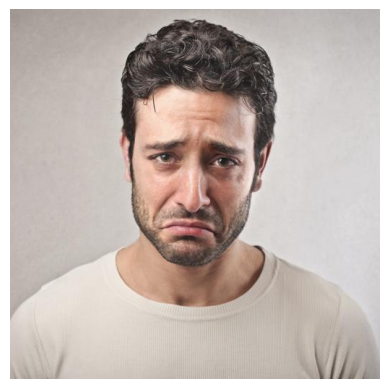

In [ ]:
img = cv2.imread(image_path)

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")
plt.show()

In [ ]:
detector = FER(mtcnn=True)

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [ ]:
detector = FER()

In [ ]:
result = detector.detect_emotions(img_rgb)

print(result)

[{'box': array([144, 121, 221, 221], dtype=int32), 'emotions': {'angry': 0.17, 'disgust': 0.0, 'fear': 0.09, 'happy': 0.0, 'sad': 0.66, 'surprise': 0.0, 'neutral': 0.08}}]


In [ ]:
if len(result) > 0:

    emotions = result[0]["emotions"]

    predicted_emotion = max(emotions, key=emotions.get)

    confidence = emotions[predicted_emotion]

    print("Predicted Emotion:", predicted_emotion)
    print("Confidence:", round(confidence*100,2), "%")

else:
    print("No face detected.")

Predicted Emotion: sad
Confidence: 66.0 %


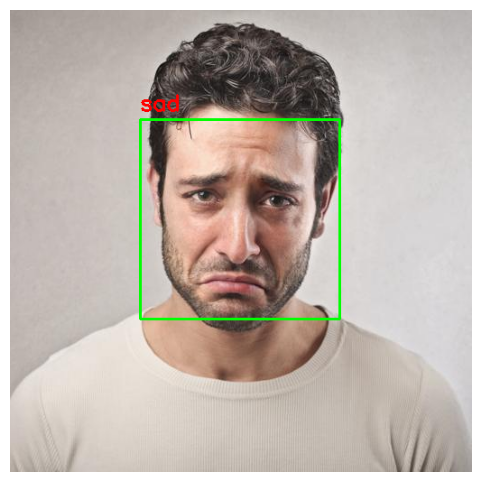

In [ ]:
if len(result) > 0:

    x, y, w, h = result[0]["box"]

    cv2.rectangle(img_rgb,(x,y),(x+w,y+h),(0,255,0),2)

    cv2.putText(img_rgb,
                predicted_emotion,
                (x,y-10),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.8,
                (255,0,0),
                2)

    plt.figure(figsize=(6,6))
    plt.imshow(img_rgb)
    plt.axis("off")
    plt.show()